# Feature processing and selection

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


from scipy.stats import gaussian_kde    # We use this to plot kernel density

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping



In [125]:
# 880 is the ID for the Support2 data.
support2 = fetch_ucirepo(id=880)

# Load the entire dataset into a pandas dataframe
# support2.data.features does not include some variables that we are interested
df = support2.data.original
display(df.head(n=2))

# Summary print outs
print(50*"+-")
print("Online data dictionary")
print("https://archive.ics.uci.edu/dataset/880/support2")

print(50*"+-")
print("Column names:\n", df.columns)

print(50*"+-")
print("Shape of the data: ", df.shape)

print(50*"+-")
print("'slos' column contains NA or null?")
print(df.slos.isna().any() == 1)


,id,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
0,1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
1,2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0


+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Online data dictionary
https://archive.ics.uci.edu/dataset/880/support2
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Column names:
 Index(['id', 'age', 'death', 'sex', 'hospdead', 'slos', 'd.time', 'dzgroup',
       'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst',
       'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday',
       'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday',
       'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea',
       'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'sfdm2',
       'adlsc'],
      dtype='object')
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
Shape of the data:  (9105, 48)
+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-

In [126]:
# Limiting the examples to patients passed away while hospitalized
df = df[df.hospdead == 1]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2360 entries, 1 to 9103
Data columns (total 48 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        2360 non-null   int64  
 1   age       2360 non-null   float64
 2   death     2360 non-null   int64  
 3   sex       2360 non-null   object 
 4   hospdead  2360 non-null   int64  
 5   slos      2360 non-null   int64  
 6   d.time    2360 non-null   int64  
 7   dzgroup   2360 non-null   object 
 8   dzclass   2360 non-null   object 
 9   num.co    2360 non-null   int64  
 10  edu       1747 non-null   float64
 11  income    1465 non-null   object 
 12  scoma     2359 non-null   float64
 13  charges   2299 non-null   float64
 14  totcst    2084 non-null   float64
 15  totmcst   1317 non-null   float64
 16  avtisst   2353 non-null   float64
 17  race      2341 non-null   object 
 18  sps       2359 non-null   float64
 19  aps       2359 non-null   float64
 20  surv2m    2359 non-null   float64
 

In [127]:
# Now that we selected patients 
# Check that the value of "death" and "hospdead" is uniformly "1".
print(50*"+-")
print("'death' and 'hospdeath' columns are all '1's?")
print(df.death.unique().all() == 1 and df.hospdead.unique().all() == 1)

# Drop columns that are now constant or irrelevant
df.drop(columns=["death", "hospdead", "id", "d.time", 
                 "dzclass", "charges", "totcst", "totmcst", 
                 "prg2m", "prg6m", "dnrday", "adlp", 
                 "adls", "meanbp", "avtisst"], inplace=True)



+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-
'death' and 'hospdeath' columns are all '1's?
True


/tmp/ipykernel_1974/651423432.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["death", "hospdead", "id", "d.time",


## Feature engineering

### Missing and bad values

In [128]:
# Missing value in features ["sps", "aps", "surv2m", "surv6m"]. 
# It turns out there is exactly one missing value for all these four features.

cols = ["sps", "aps", "surv2m", "surv6m", "scoma"]
df["sps_aps_surv_missing"] = df[cols].isna().any(axis=1).astype(int)
df[cols]

impute_values = {
    "sps": df["sps"].mean(),       #  
    "aps": df["aps"].mean(),
    "surv2m": df["surv2m"].mean(),
    "surv6m": df["surv6m"].mean(),
    "scoma": df["scoma"].mean()
}

df[cols] = df[cols].fillna(impute_values)


df["dnr"] = df["dnr"].fillna("missing")
df["income"] = df["income"].fillna("missing")
df["race"] = df["race"].fillna("missing")
df["sfdm2"] = df["sfdm2"].fillna("missing")

df["wblc"] = df["wblc"].fillna(9) # Using data curator's suggested fill-in value for missing value
df["pafi"] = df["pafi"].fillna(333.3) # Using data curator's suggested fill-in value for missing value
df["alb"] = df["alb"].fillna(3.5) # Using data curator's suggested fill-in value for missing value
df["bili"] = df["bili"].fillna(1.01) # Using data curator's suggested fill-in value for missing value
df["crea"] = df["crea"].fillna(1.01) # Using data curator's suggested fill-in value for missing value
df["bun"] = df["bun"].fillna(6.51) # Using data curator's suggested fill-in value for missing value
df["urine"] = df["urine"].fillna(2502) # Using data curator's suggested fill-in value for missing value

df["ph"] = df["ph"].fillna(df["ph"].median()) # It makes sense to replace missing ph with sample median
df["glucose"] = df["glucose"].fillna(df["glucose"].median()) # It makes sense to replace missing ph with sample median

df["resp"] = df["resp"].replace(0, np.nan)
df["resp"] = df["resp"].fillna(df["resp"].median()) # It doesn't make sense to have 0 resperation rate!

df["hrt"] = df["hrt"].replace([0, 1], np.nan)
df["hrt"] = df["hrt"].fillna(df["hrt"].median()) # It doesn't make sense to have 0 heart rate!




# Define a function that turns education years into bins including 'missing'
def edu_bins(edu):
    if pd.isna(edu):
        return "missing"
    elif edu < 12:
        return "pre_hs" # did not complete highschool 
    elif edu == 12:
        return "hs"
    elif edu < 16:
        return "some_college"
    else:
        return "college_or_higher"

df["edu_bins"] = df.edu.apply(edu_bins)
df["edu_bins"]
df.drop(columns=["edu"], inplace=True)



/tmp/ipykernel_1974/3834295066.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sps_aps_surv_missing"] = df[cols].isna().any(axis=1).astype(int)
/tmp/ipykernel_1974/3834295066.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols] = df[cols].fillna(impute_values)
/tmp/ipykernel_1974/3834295066.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

### Outcome variables (choose one for each task)

In [129]:
# Median-based binary
slos_median = df["slos"].median()
df["slos_bin_median"] = (df["slos"] > slos_median).astype(int)

# 30-day binary
df["slos_bin_30"] = (df["slos"] > 30).astype(int)

# 3-class: [0–7], (7–30], (30+]
def slos_3class(x):
    if x <= 7:
        return 0
    elif x <= 30:
        return 1
    else:
        return 2

df["slos_3class_7_30"] = df["slos"].apply(slos_3class)

# 5-class: [0–7], (7–30], (30–60], (60–180], (180+]
def slos_5class_fixed(x):
    if x <= 7:
        return 0
    elif x <= 30:
        return 1
    elif x <= 60:
        return 2
    elif x <= 180:
        return 3
    else:
        return 4

df["slos_5class_fixed"] = df["slos"].apply(slos_5class_fixed)

# 5-class: quintiles (equal-sized bins)
df["slos_5class_quantile"] = pd.qcut(df["slos"], q=5, labels=False)


/tmp/ipykernel_1974/402101551.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["slos_bin_median"] = (df["slos"] > slos_median).astype(int)
/tmp/ipykernel_1974/402101551.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["slos_bin_30"] = (df["slos"] > 30).astype(int)
/tmp/ipykernel_1974/402101551.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

### Encode categorical features

In [130]:
categorical_features = ["sex", "dzgroup", "income", "race",
                        "ca", "dnr", "sfdm2", "edu_bins"]


df = pd.get_dummies(df, columns=categorical_features, drop_first=True)


## Select outcome variable for the learning task

### Define a function to pick outcome variable

In [131]:
def select_outcome(df, outcome_col):
    """
    Returns X, y after dropping all other outcome columns and 'slos'.
    """
    outcome_cols = [
        "slos", "slos_bin_median", "slos_bin_30",
        "slos_3class_7_30", "slos_5class_fixed", "slos_5class_quantile"
    ]
    X = df.drop(columns=[col for col in outcome_cols if col != outcome_col])
    y = df[outcome_col]
    return X.drop(columns=[outcome_col]), y


### Choose outcome variable

In [132]:
X, y = select_outcome(df, "slos_bin_median")

## Split data

In [133]:
# First split: 60% train, 40% validation and test
X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y, test_size=0.4, random_state=2, stratify=y
)

# Second split: 20% (of total number of examples) val, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=2, stratify=y_val_test
)


## Baseline model: logistic regression

### Fitting baseline model

In [134]:

# Scale the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Baseline model: simple logistic regression
baseline_model = LogisticRegression(max_iter=10000)
baseline_model.fit(X_train_scaled, y_train)

y_train_pred = baseline_model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Training Confusion Matrix:\n {confusion_matrix(y_train, y_train_pred)}")

Training Accuracy: 0.701
Training Confusion Matrix:
 [[504 223]
 [201 488]]


### Accuracy on validation data and confusion matrix

In [135]:
y_val_pred = baseline_model.predict(X_val_scaled)
val_acc = accuracy_score(y_val, y_val_pred)

print(classification_report(y_val, y_val_pred))
print(f"Validation accuracy: {val_acc:.3f}")

              precision    recall  f1-score   support

           0       0.73      0.71      0.72       242
           1       0.70      0.73      0.71       230

    accuracy                           0.72       472
   macro avg       0.72      0.72      0.72       472
weighted avg       0.72      0.72      0.72       472

Validation accuracy: 0.716


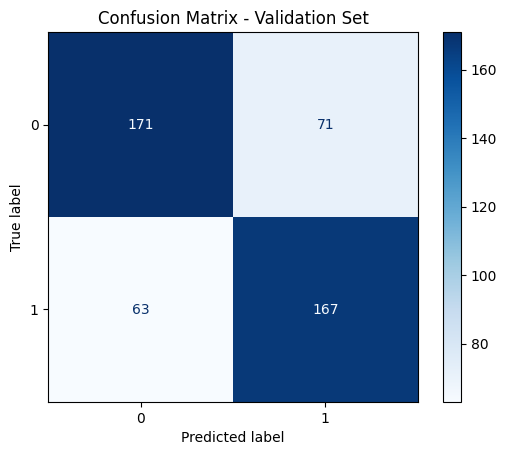

In [136]:
# Compute and display confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Validation Set")
plt.show()

## TensorFlow model

In [118]:
def build_binary_model(input_dim,
                       hidden_layer_sizes=[],
                       activation='relu',
                       optimizer='adam',
                       learning_rate=0.001,
                       metric='accuracy'):
    """
    Build a Keras binary classification model for tabular data.
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(input_dim,)))

    for units in hidden_layer_sizes:
        model.add(tf.keras.layers.Dense(units, activation=activation))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    if optimizer.lower() == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer.lower() == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError("Unsupported optimizer. Use 'sgd' or 'adam'.")

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=[metric])
    return model


In [119]:
model = build_binary_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layer_sizes=[64, 32],
    activation='relu',
    optimizer='adam',
    learning_rate=0.0001,
    metric='accuracy'
)


In [120]:
# Step 2: Optional early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Step 3: Fit the model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
#    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5438 - loss: 0.6988 - val_accuracy: 0.5381 - val_loss: 0.6931
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5795 - loss: 0.6744 - val_accuracy: 0.5763 - val_loss: 0.6761
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6013 - loss: 0.6575 - val_accuracy: 0.5996 - val_loss: 0.6630
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6305 - loss: 0.6432 - val_accuracy: 0.6186 - val_loss: 0.6522
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6468 - loss: 0.6307 - val_accuracy: 0.6292 - val_loss: 0.6430
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6581 - loss: 0.6194 - val_accuracy: 0.6441 - val_loss: 0.6353
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6730 - loss: 0.6092 - val_accuracy: 0.6568 - val_loss: 0.6285
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6817 - loss: 0.5999 - val_accuracy: 0.6674 - val_loss:

In [121]:
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.3f}")

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.3f}")

# Classification report
y_test_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
print(classification_report(y_test, y_test_pred))


Validation Accuracy: 0.689
Test Accuracy: 0.659
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       242
           1       0.64      0.67      0.66       230

    accuracy                           0.66       472
   macro avg       0.66      0.66      0.66       472
weighted avg       0.66      0.66      0.66       472



In [122]:

# Build the model
model = tf.keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),



    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
#    layers.Dense(16, activation="relu"),
#    layers.Dense(8, activation="relu"),
    layers.Dropout(0.2),


    layers.Dense(1, activation="sigmoid")  # binary classification
])

# Compile
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Optional: early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on validation and test sets
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.3f}")

test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.3f}")

# Classification report
y_test_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
print(classification_report(y_test, y_test_pred))


Epoch 1/50
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6016 - loss: 0.7057 - val_accuracy: 0.6822 - val_loss: 0.5961
Epoch 2/50
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6990 - loss: 0.5732 - val_accuracy: 0.6674 - val_loss: 0.5859
Epoch 3/50
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7450 - loss: 0.5315 - val_accuracy: 0.6758 - val_loss: 0.5926
Epoch 4/50
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7578 - loss: 0.4928 - val_accuracy: 0.6801 - val_loss: 0.6074
Epoch 5/50
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7790 - loss: 0.4634 - val_accuracy: 0.6610 - val_loss: 0.6402
Epoch 6/50
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8075 - loss: 0.4291 - val_accuracy: 0.6780 - val_loss: 0.6738
Epoch 7/50
1416/1416 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8186 - loss: 0.3908 - val_accuracy: 0.6631 - val_loss: 0.7046
Validation Accuracy: 0.667
Test Accuracy: 0.663
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
  

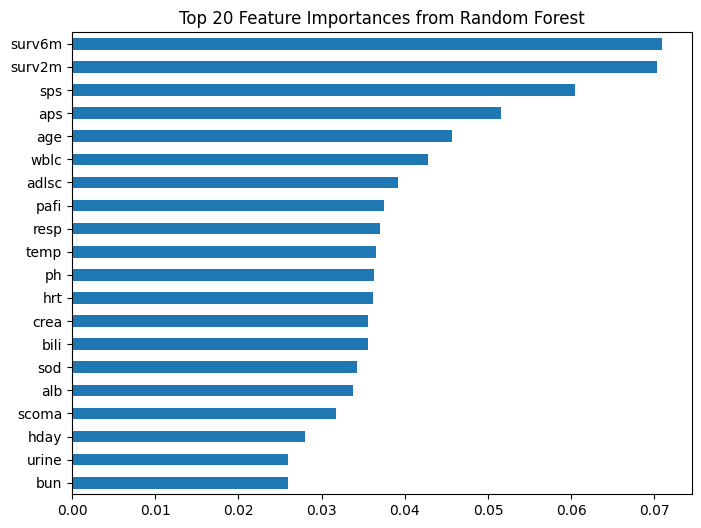

In [ ]:

# 1. Fit a Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# 2. Get feature importances
importances = rf.feature_importances_

# 3. Optional: plot feature importance

feat_importance = pd.Series(importances, index=X_train.columns)
top_feats = feat_importance.sort_values(ascending=False).head(20)
top_feats.plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Feature Importances from Random Forest")
plt.gca().invert_yaxis()
plt.show()
